In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import statsmodels.api as sm
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

[*********************100%***********************]  2 of 2 completed


Text(0.5, 1.0, 'Simple Linear Regression')

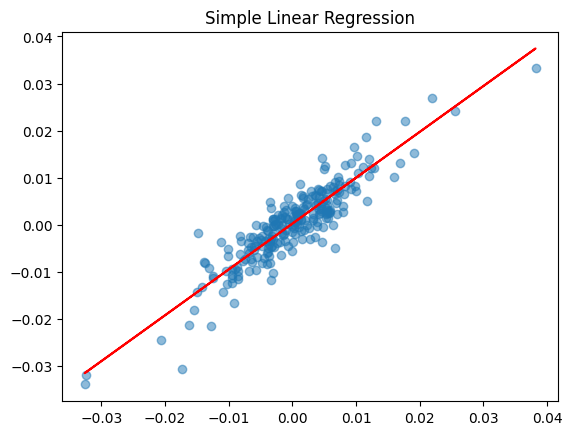

In [41]:
end = dt.date.today()
start = end - dt.timedelta(365)
df = yf.download(["^NSEI", "^NSEBANK"], start=start, end=end, auto_adjust=True)['Close']
df.rename(columns = {'^NSEBANK':'bank','^NSEI':'nse',}, inplace = True)
df
# Creating Returns
returns = df.pct_change().dropna()
x = returns['nse']
y = returns['bank']
# Model Training
x = sm.add_constant(x)
model = sm.OLS(y,x).fit()


# Plotting
plt.scatter(returns['nse'], returns['bank'],alpha=0.5,label='dailyline')
plt.plot(returns['nse'],model.fittedvalues,color = 'red',label = 'regression line')
plt.title('Simple Linear Regression')

In [42]:
df

Ticker,bank,nse
Date,,
2025-03-21,50593.550781,23350.400391
2025-03-24,51704.949219,23658.349609
2025-03-25,51607.949219,23668.650391
2025-03-26,51209.000000,23486.849609
2025-03-27,51575.851562,23591.949219
...,...,...
2026-03-16,54413.398438,23408.800781
2026-03-17,54876.000000,23581.150391
2026-03-18,55326.050781,23777.800781


In [43]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   bank   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     1138.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           7.69e-94
Time:                        06:30:58   Log-Likelihood:                 1033.9
No. Observations:                 246   AIC:                            -2064.
Df Residuals:                     244   BIC:                            -2057.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      1.155      0.2